# Option Pricing and Local Volatility Extraction via Dual-Network PINNs

The traditional Black-Scholes framework relies on the fundamental assumption of constant volatility. This project extends the standard model by substituting constant volatility with a dynamic Local Volatility surface. The provided implementation constructs a Dual-Network Physics-Informed Neural Network (PINN) designed to approximate both the call option price $V(S,t)$ and the local volatility $\sigma(S,t)$ directly from raw market observations.



## Black-Scholes equation


The Black-Scholes Partial Differential Equation (PDE) governs the price of European options and can be derived from basic principles of hedging, risk neutrality, and no-arbitrage.

For a European call option with value $V(S,t)$ (the price of the option $V$ over time $t$ and stock price $S$:)
$$\frac{\partial V}{\partial t} = \frac{1}{2}\sigma(S,t)^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV$$

where:
- $r$ (Risk-Free Interest Rate): The theoretical rate of return of an investment with zero risk (like a short-term government bond).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import norm
from typing import Union

## Dual-Network Architecture

The neural architecture splits the learning process into two parallel Multi-Layer Perceptrons.  
- Pricing Sub-Network: This network ingests normalized Spot Price ($S$), Strike ($K$), and Time to Maturity ($t$) to predict the option's fair value.  
- Volatility Sub-Network: This parallel network ingests only $S$ and $t$ to output the instantaneous local volatility.
- Activation Functions: Both networks utilize Sigmoid Linear Units (SiLU). The infinitely differentiable nature of the SiLU activation ensures that second-order spatial derivatives do not collapse to zero during training.  
- Additionally, the volatility network utilizes a softplus activation on its output layer to ensure strict positivity.


In [2]:
class BlackScholes(nn.Module):
    """
    Dual-Network Physics-Informed Neural Network (PINN) for inverse options pricing.
    Simultaneously learns the option price and the underlying local volatility surface.
    """
    def __init__(self, S_max=400.0, K_max=400.0, T_max=2.0, lr=0.001):
        super(BlackScholes, self).__init__()

        # Scaling factors to normalize inputs and outputs
        self.S_max = S_max
        self.K_max = K_max
        self.T_max = T_max

        # Learnable uncertainty weights
        self.w_data = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.w_pde = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.w_term = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.w_bc0 = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.w_bcmax = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))
        self.w_smooth = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

        # Learnable risk-free rate
        self.r = nn.Parameter(torch.tensor([0.04], dtype=torch.float32))

        self.price_net = nn.Sequential(
            nn.Linear(3, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1)
        )

        self.vol_net = nn.Sequential(
            nn.Linear(2, 32),
            nn.SiLU(),
            nn.Linear(32, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

        # Loss criterion and optimizer
        self.criterion = nn.MSELoss()
        self.optimizer_adam = optim.Adam(self.parameters(), lr=lr)

    def forward_price(self, S, K, t):
        """Predicts the option price given Spot, Strike, and Time to Maturity."""
        # Normalize inputs to [-1, 1] for stable gradient flow
        S_norm = 2.0 * (S / self.S_max) - 1.0
        K_norm = 2.0 * (K / self.K_max) - 1.0
        t_norm = 2.0 * (t / self.T_max) - 1.0

        inputs = torch.cat([S_norm, K_norm, t_norm], dim=1)
        V_raw = self.price_net(inputs)

        # Scale output back to the financial domain
        return V_raw * K

    def forward_vol(self, S, t):
        """Predicts the local volatility given Spot and Time to Maturity."""
        S_norm = 2.0 * (S / self.S_max) - 1.0
        t_norm = 2.0 * (t / self.T_max) - 1.0

        inputs = torch.cat([S_norm, t_norm], dim=1)
        raw_vol = self.vol_net(inputs)

        # Ensure volatility remains strictly positive
        return torch.nn.functional.softplus(raw_vol) + 1e-4

    def diff_eq(self, S, K, t):
        """Calculates the Black-Scholes PDE residual and volatility smoothness penalty."""
        # Enable gradient tracking for inputs
        S = S.clone().requires_grad_(True)
        t = t.clone().requires_grad_(True)

        V = self.forward_price(S, K, t)
        sigma_dynamic = self.forward_vol(S, t)

        # Black-Scholes PDE formulation
        V_t = torch.autograd.grad(V, t, grad_outputs=torch.ones_like(V), create_graph=True)[0]
        V_S = torch.autograd.grad(V, S, grad_outputs=torch.ones_like(V), create_graph=True)[0]
        V_SS = torch.autograd.grad(V_S, S, grad_outputs=torch.ones_like(V_S), create_graph=True)[0]

        pde_residual = V_t - (0.5 * (sigma_dynamic**2) * (S**2) * V_SS + self.r * S * V_S - self.r * V)

        # Compute volatility gradients for the smoothness penalty
        sigma_S = torch.autograd.grad(sigma_dynamic, S, grad_outputs=torch.ones_like(sigma_dynamic), create_graph=True)[0]
        sigma_t = torch.autograd.grad(sigma_dynamic, t, grad_outputs=torch.ones_like(sigma_dynamic), create_graph=True)[0]
        smoothness_penalty = (sigma_S)**2 + (sigma_t)**2

        return pde_residual, smoothness_penalty

    def sample_points(self, num_colloc, num_bc):
        """Generates collocation and boundary points"""
        min_S, min_K = self.S_max * 0.01, self.K_max * 0.01

        # Uniform interior points
        S_int = torch.rand((num_colloc, 1)) * (self.S_max - min_S) + min_S
        K_int = torch.rand((num_colloc, 1)) * (self.K_max - min_K) + min_K
        t_int = torch.rand((num_colloc, 1)) * self.T_max

        # Terminal boundary points (t = 0 payoff)
        S_term = torch.rand((num_bc, 1)) * (self.S_max - min_S) + min_S
        K_term = torch.rand((num_bc, 1)) * (self.K_max - min_K) + min_K

        # S = 0 boundary points
        S_bc0 = torch.zeros((num_bc, 1))
        K_bc0 = torch.rand((num_bc, 1)) * (self.K_max - min_K) + min_K
        t_bc0 = torch.rand((num_bc, 1)) * self.T_max

        # S = S_max boundary points
        S_bcmax = torch.full((num_bc, 1), self.S_max)
        K_bcmax = torch.rand((num_bc, 1)) * (self.K_max - min_K) + min_K
        t_bcmax = torch.rand((num_bc, 1)) * self.T_max

        return S_int, K_int, t_int, S_term, K_term, S_bc0, K_bc0, t_bc0, S_bcmax, K_bcmax, t_bcmax

    def loss_function(self, S_data, K_data, t_data, V_data, S_int, K_int, t_int, S_term, K_term, S_bc0, K_bc0, t_bc0, S_bcmax, K_bcmax, t_bcmax):
        """Calculates the aggregated, adaptively-weighted loss."""

        # 1. Data Loss: Matches predictions against observed market data
        V_pred = self.forward_price(S_data, K_data, t_data)
        loss_data = self.criterion(V_pred / self.K_max, V_data / self.K_max)

        # 2. PDE & Smoothness Loss: Enforces physical laws and surface regularity
        pde_res, smoothness_pen = self.diff_eq(S_int, K_int, t_int)
        loss_pde = self.criterion(pde_res / self.K_max, torch.zeros_like(pde_res))
        loss_smooth = torch.mean(smoothness_pen)

        # 3. Boundary Conditions (BC): Enforces payoff structures at extremes
        t_term = torch.zeros_like(S_term)
        V_term_pred = self.forward_price(S_term, K_term, t_term)
        V_term_true = torch.maximum(S_term - K_term, torch.zeros_like(S_term))
        loss_term = self.criterion(V_term_pred / self.K_max, V_term_true / self.K_max)

        V_bc0_pred = self.forward_price(S_bc0, K_bc0, t_bc0)
        loss_bc0 = self.criterion(V_bc0_pred / self.K_max, torch.zeros_like(V_bc0_pred))

        V_bcmax_pred = self.forward_price(S_bcmax, K_bcmax, t_bcmax)
        V_bcmax_true = self.S_max - K_bcmax * torch.exp(-self.r * t_bcmax)
        loss_bcmax = self.criterion(V_bcmax_pred / self.K_max, V_bcmax_true / self.K_max)

        loss_data_adaptive = torch.exp(-self.w_data) * loss_data + self.w_data
        loss_pde_adaptive = torch.exp(-self.w_pde) * loss_pde + self.w_pde
        loss_term_adaptive = torch.exp(-self.w_term) * loss_term + self.w_term
        loss_bc0_adaptive = torch.exp(-self.w_bc0) * loss_bc0 + self.w_bc0
        loss_bcmax_adaptive = torch.exp(-self.w_bcmax) * loss_bcmax + self.w_bcmax
        loss_smooth_adaptive = torch.exp(-self.w_smooth) * loss_smooth + self.w_smooth

        total_loss = loss_data_adaptive + loss_pde_adaptive + loss_term_adaptive + loss_bc0_adaptive + loss_bcmax_adaptive + loss_smooth_adaptive

        # Relative Error to assess overall stability
        rel_l2_error = torch.sqrt(torch.sum((V_pred - V_data)**2)) / (torch.sqrt(torch.sum(V_data**2)) + 1e-8)

        return total_loss, rel_l2_error

    def fit(self, S_data, K_data, t_data, V_data, epochs=8000, num_colloc=2000, num_bc=500):
        """Trains the network using pre-initialized optimizers."""
        self.train()
        loss_history = []
        error_history = []
        device = S_data.device

        for epoch in range(epochs):
            self.optimizer_adam.zero_grad()

            # Resample points periodically to prevent overfitting to a static grid
            if epoch % 1000 == 0:
                S_int, K_int, t_int, S_term, K_term, S_bc0, K_bc0, t_bc0, S_bcmax, K_bcmax, t_bcmax = self.sample_points(num_colloc, num_bc)
                S_int, K_int, t_int = S_int.to(device), K_int.to(device), t_int.to(device)
                S_term, K_term = S_term.to(device), K_term.to(device)
                S_bc0, K_bc0, t_bc0 = S_bc0.to(device), K_bc0.to(device), t_bc0.to(device)
                S_bcmax, K_bcmax, t_bcmax = S_bcmax.to(device), K_bcmax.to(device), t_bcmax.to(device)

            loss, error = self.loss_function(S_data, K_data, t_data, V_data, S_int, K_int, t_int, S_term, K_term, S_bc0, K_bc0, t_bc0, S_bcmax, K_bcmax, t_bcmax)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)

            self.optimizer_adam.step()

            # Weight clamping
            with torch.no_grad():
                self.w_pde.clamp_(min=-4.0, max=4.0)
                self.w_smooth.clamp_(min=-4.0, max=4.0)
                self.w_term.clamp_(min=-4.0, max=4.0)
                self.w_bc0.clamp_(min=-4.0, max=4.0)
                self.w_bcmax.clamp_(min=-4.0, max=4.0)
                self.w_data.clamp_(min=-4.0, max=4.0)

            loss_history.append(loss.item())
            error_history.append(error.item())
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}| Total Loss: {loss.item():.6e}")


        return loss_history, error_history

## Black-Scholes formula: the analytical solution
- For a European Call Option (the right to buy a stock at a specific price), the theoretical price $C$ is:
$$V = S_0 N(d_1) - K e^{-rT} N(d_2)$$
- Where the terms $d_1$ and $d_2$ are calculated as:$$d_1 = \frac{\ln(S_0/K) + (r + \frac{\sigma^2}{2})T}{\sigma \sqrt{T}}$$$$d_2 = d_1 - \sigma \sqrt{T}$$
- $N(d_2)$ represents the risk-adjusted probability that the option will expire "in-the-money" (meaning it will be profitable to exercise).
- $N(d_1)$ is a bit more complex; it acts as a conditional probability factor. It essentially scales the stock price to represent the expected value of the asset given that the option finishes in the money.

In [3]:
def black_scholes_call(
    S: Union[float, np.ndarray],
    K: Union[float, np.ndarray],
    t: Union[float, np.ndarray],
    r: float,
    sigma: Union[float, np.ndarray]
) -> Union[float, np.ndarray]:
    """
    Computes the theoretical price of a European call option using the
    standard Black-Scholes-Merton formula.
    """
    t_safe = np.maximum(t, 1e-8)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * t_safe) / (sigma * np.sqrt(t_safe))
    d2 = d1 - sigma * np.sqrt(t_safe)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * t_safe) * norm.cdf(d2)

    return call_price

## Dataset Preprocessing
- Dataset Preprocessing: The model trains on real-world options data, requiring specific preprocessing steps.  
- Time remaining to expiration is normalized into annualized terms ($t$).  
- A "Mid" price is calculated by averaging the Bid and Ask prices to serve as the target fair market value.  
- To focus the PINN on the most relevant liquid regions, extreme short-term expirations (less than 0.05 years) and deep out-of-the-money or deep in-the-money tails are trimmed from the primary training loop.

In [4]:
df = pd.read_csv('calls_dataset.csv')

df = df.dropna(subset=['bid', 'ask'])

# Calculate the mid-price to serve as the target option value (V_data)
df['mid'] = (df['bid'] + df['ask']) / 2.0

# Convert time to maturity from days into years (t)
df['t'] = df['remaining'] / 365.0

# Outlier filtering and domain bounding
# Filter out extreme values to keep the PINN focused on the most liquid/relevant regions.

S_median = df['price'].median()
df_filtered = df[(df['price'] > S_median * 0.5) & (df['price'] < S_median * 1.5) &
            (df['strike'] > S_median * 0.5) & (df['strike'] < S_median * 1.5) &
            (df['t'] > 0.05) & (df['t'] < 2.0)]

S_max = float(df_filtered['price'].max())
K_max = float(df_filtered['strike'].max())
T_max = float(df_filtered['t'].max())

## Training Dynamics and Stability Mechanisms: Optimization Challenges and Regularization
During training, the loss curve exhibits negative convergence, with the total loss plunges to approximately -25. Consequently, a relative $\mathcal{L}_2$ error metric is calculated to accurately assess overall model convergence.  
- The mathematical formulation relies heavily on the second-order spatial derivative (Gamma, $\Gamma$).  
- The true mathematical Gamma spikes toward infinity as time approaches zero.  
- If random collocation points are sampled too close to an expiration time of 0, the resulting massive derivatives send destructive gradients backward through the network, causing the model to learn noise after roughly 8000 epochs.  
- Furthermore, if the PDE loss becomes extremely small, the optimizer may push the learnable weight $w_i$ into negative values, resulting in an exponentially large $e^{-w_i}\mathcal{L}_i$ term.  
- To overcome these catastrophic gradient explosions, gradient clipping is applied to cap gradient norms at 1.0.  
- Additionally, the adaptive weights ($w_i$) are clamped within a fixed interval of $[-4.0, 4.0]$ to maintain learning stability.

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
S_data = torch.tensor(df_filtered['price'].values, dtype=torch.float32).unsqueeze(1).to(device)
K_data = torch.tensor(df_filtered['strike'].values, dtype=torch.float32).unsqueeze(1).to(device)
t_data = torch.tensor(df_filtered['t'].values, dtype=torch.float32).unsqueeze(1).to(device)
V_data = torch.tensor(df_filtered['mid'].values, dtype=torch.float32).unsqueeze(1).to(device)

# Model setup and training
model = BlackScholes(S_max=S_max, K_max=K_max, T_max=T_max, lr=5e-4).to(device)

losses,error = model.fit(S_data, K_data, t_data, V_data, epochs=20000, num_colloc=10000, num_bc=10000)
learned_r = model.r.item()
print(f"\nExtracted Risk-Free Rate (r): {learned_r * 100:.2f}%")

Epoch 0| Total Loss: 3.985547e-01
Epoch 1000| Total Loss: -2.970471e+00
Epoch 2000| Total Loss: -5.985870e+00
Epoch 3000| Total Loss: -8.990746e+00
Epoch 4000| Total Loss: -1.198734e+01
Epoch 5000| Total Loss: -1.496886e+01
Epoch 6000| Total Loss: -1.792785e+01
Epoch 7000| Total Loss: -2.083409e+01
Epoch 8000| Total Loss: -2.363611e+01
Epoch 9000| Total Loss: -2.393973e+01
Epoch 10000| Total Loss: -2.393989e+01
Epoch 11000| Total Loss: -2.394032e+01
Epoch 12000| Total Loss: -2.394069e+01
Epoch 13000| Total Loss: -2.394090e+01
Epoch 14000| Total Loss: -2.394109e+01
Epoch 15000| Total Loss: -2.394124e+01
Epoch 16000| Total Loss: -2.394127e+01
Epoch 17000| Total Loss: -2.394140e+01
Epoch 18000| Total Loss: -2.394143e+01
Epoch 19000| Total Loss: -2.394150e+01

Extracted Risk-Free Rate (r): 7.00%


## Physics-Informed Loss Formulation: Self-Calibrating Objective Function
The model is optimized by simultaneously minimizing multiple objectives: data error ($\mathcal{L}_{Data}$), boundary errors ($\mathcal{L}_{BC}$, $\mathcal{L}_{Term}$, $\mathcal{L}_{Bmax}$), smoothness penalty ($\mathcal{L}_{Smooth}$), and the PDE residual ($\mathcal{L}_{PDE}$).  Because these tasks operate on fundamentally different gradient scales, the model implements a dynamic, self-calibrating loss formulation inspired by Kendall et al. (2018).  The total loss function is defined as:$$\mathcal{L}_{Total} = \sum_i \left( e^{-w_i}\mathcal{L}_i + w_i \right)$$  
- In this formulation, $w_i$ acts as a trainable parameter representing the network's uncertainty for each specific task.
- This structure functions as an automated mathematical equalizer.  
- If the PDE loss generates unstable gradients, the network autonomously increases the penalty parameter $w_{PDE}$, which dampens the gradient via the $e^{-w_i}$ multiplier while simultaneously incurring a linear penalty $+w_i$ to prevent the task from being ignored.  

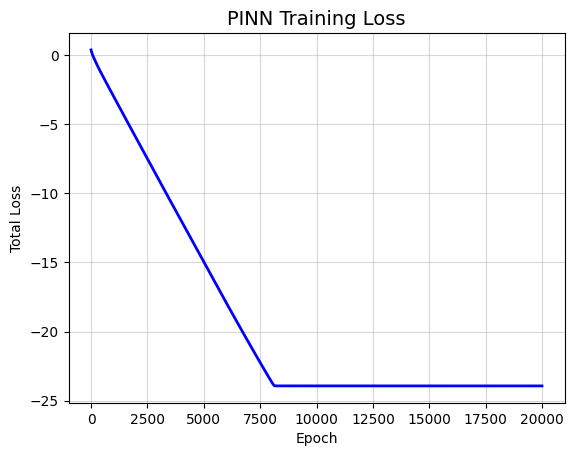

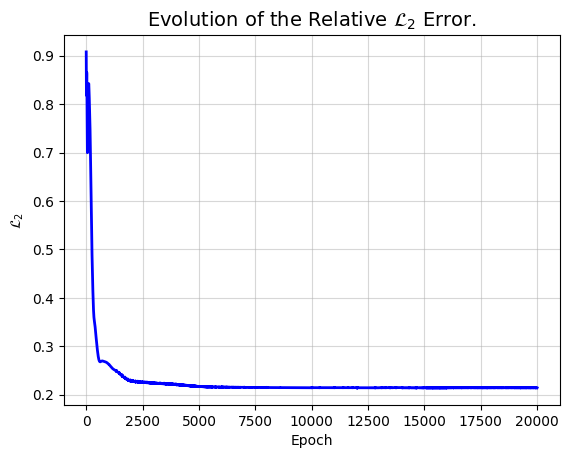

In [6]:
plt.plot(losses, color='blue', linewidth=2)
plt.title('PINN Training Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True, alpha=0.5)
plt.show()

plt.plot(error, color='blue', linewidth=2)
plt.title(r'Evolution of the Relative $\mathcal{L}_2$ Error.', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel(r'$\mathcal{L}_2$')
plt.grid(True, alpha=0.5)
plt.show()

In [7]:
S0 = float(df_filtered['price'].median())
device = S_data.device

# Generate 2D Domain Meshes for S and t
# Fix Strike (K) as a baseline anchor, letting Spot and Time vary continuously.
K_fixed = float(df_filtered['strike'].median())
S_space = np.linspace(K_fixed * 0.5, K_fixed * 1.75, 50)
t_space = np.linspace(0.05, T_max, 50)

S_mesh, t_mesh = np.meshgrid(S_space, t_space)
S_flat = S_mesh.flatten()
t_flat = t_mesh.flatten()
K_flat = np.full_like(S_flat, K_fixed)

S_test_3d = torch.tensor(S_flat, dtype=torch.float32).unsqueeze(1).to(device).requires_grad_(True)
t_test_3d = torch.tensor(t_flat, dtype=torch.float32).unsqueeze(1).to(device).requires_grad_(True)
K_test_3d = torch.tensor(K_flat, dtype=torch.float32).unsqueeze(1).to(device)

In [8]:
# PINN's results
V_pinn = model.forward_price(S_test_3d, K_test_3d, t_test_3d)
V_pinn_flat = V_pinn.cpu().detach().numpy().flatten()
sigma_pinn_flat = model.forward_vol(S_test_3d, t_test_3d).cpu().detach().numpy().flatten()
learned_r = float(model.r.item())

V_pinn_surface = V_pinn_flat.reshape(S_mesh.shape)
sigma_pinn_surface = sigma_pinn_flat.reshape(S_mesh.shape)

# Analytical Truth
V_exact_flat = black_scholes_call(
    S=S_flat,
    K=K_fixed,
    t=t_flat,
    r=learned_r,
    sigma=sigma_pinn_flat
)
V_exact_surface = V_exact_flat.reshape(S_mesh.shape)

df_3d = df_filtered[(df_filtered['strike'] > K_fixed * 0.98) & (df_filtered['strike'] < K_fixed * 1.02)]


## Empirical Results and Topographical Analysis
The trained PINN's dynamic price surface almost perfectly overlaps the analytical constant-volatility baseline across the spatial-temporal domain, effectively validating the Black-Scholes theoretical structure against real market data.

In [9]:
fig_price = go.Figure()

# Analytical Black-Scholes
fig_price.add_trace(
    go.Surface(
        x=S_mesh, y=t_mesh, z=V_exact_surface,
        colorscale="Greys", opacity=0.9, showscale=False,
        name="Analytical BS", hoverinfo="skip"
    )
)

# PINN model
fig_price.add_trace(
    go.Surface(
        x=S_mesh, y=t_mesh, z=V_pinn_surface,
        colorscale="Viridis", opacity=0.9, showscale=True,
        colorbar=dict(title=r"V(S, t)", len=0.7),
        name="PINN Price Prediction"
    )
)

# Real data
fig_price.add_trace(
    go.Scatter3d(
        x=df_3d['price'], y=df_3d['t'], z=df_3d['mid'],
        mode='markers',
        marker=dict(size=4, color='red', opacity=0.5),
        name='Market Data',
        showlegend=True
    )
)
fig_price.update_layout(
    title=dict(
        text=f"European Call Option Price Comparison, PINN vs Analytical Black-Scholes<br><sub> and Real Data",
        x=0.5
    ),
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=80, b=10),
    scene=dict(
        xaxis_title="Spot Price (S)",
        yaxis_title="Time to Maturity (t)",
        zaxis_title="Option Value (V)"
    )
)

fig_price.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='cyan', width=6),
    name='PINN Dynamic Surface',
    showlegend=True
))


fig_price.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='grey', width=6),
    name='Analytical BS Surface',
    showlegend=True
))
fig_price.update_layout(
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=12)
    )
)

fig_price.show()

## Local Volatility Surface
The extracted volatility surface exhibits an asymmetric "valley" structure:
-  Near the central Spot Price, the volatility drops to a minimum of approximately 0.18.  
- As the Spot Price trends toward 100, the local volatility spikes aggressively over 0.26.  

In [10]:
fig_vol = go.Figure()

# Local volatility
fig_vol.add_trace(
    go.Surface(
        x=S_mesh, y=t_mesh, z=sigma_pinn_surface,
        colorscale="Plasma", showscale=True,
        colorbar=dict(title="Volatility (σ)", len=0.7),
        name="PINN Local Volatility"
    )
)

fig_vol.update_layout(
    title=dict(
        text="PINN Local Volatility Surface σ(S, t)",
        x=0.5
    ),
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=80, b=10),
    scene=dict(
        xaxis_title="Spot Price (S)",
        yaxis_title="Time to Maturity (t)",
        zaxis_title="Local Volatility (σ)"
    )
)

fig_vol.show()

## PINN's advantage: the Greeks

A practical advantage of PINN-based pricing over traditional numerical schemes is that the Greeks (the partial derivatives of the option price) can be calculate for free via via automatic differentiation (using `torch.autograd.grad`), while the latter need separate finite-difference evaluations.

In this case for the Delta:

- $\Delta = \frac{\partial V}{\partial S} = \Delta_V = N(d_1)$
- Delta measures the rate of change of the option price with respect to the underlying stock price.
- Example: If you own a Call option with a Delta of $0.60$, and the stock price goes up by 1.00, your option price will increase by approximately $0.60.

In [11]:
# PINN's Greeks
delta_nodes = torch.autograd.grad(V_pinn, S_test_3d, grad_outputs=torch.ones_like(V_pinn), create_graph=True)[0]
gamma_nodes = torch.autograd.grad(delta_nodes, S_test_3d, grad_outputs=torch.ones_like(delta_nodes), create_graph=True)[0]
theta_nodes = -torch.autograd.grad(V_pinn, t_test_3d, grad_outputs=torch.ones_like(V_pinn), create_graph=True)[0]

delta_pinn_surf = delta_nodes.detach().cpu().numpy().reshape(S_mesh.shape)
gamma_pinn_surf = gamma_nodes.detach().cpu().numpy().reshape(S_mesh.shape)
theta_pinn_surf = theta_nodes.detach().cpu().numpy().reshape(S_mesh.shape)

# Analytical Greeks
d1 = (np.log(S_mesh / K_fixed) + (learned_r + 0.5 * sigma_pinn_surface**2) * t_mesh) / (sigma_pinn_surface * np.sqrt(t_mesh))
d2 = d1 - sigma_pinn_surface * np.sqrt(t_mesh)

delta_exact_surf = norm.cdf(d1)
gamma_exact_surf = norm.pdf(d1) / (S_mesh * sigma_pinn_surface * np.sqrt(t_mesh))
theta_exact_surf = -(S_mesh * norm.pdf(d1) * sigma_pinn_surface) / (2 * np.sqrt(t_mesh)) - learned_r * K_fixed * np.exp(-learned_r * t_mesh) * norm.cdf(d2)

In [12]:
# Delta
fig_Delta = go.Figure()

fig_Delta.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=delta_pinn_surf, colorscale='Viridis', opacity=0.9, showscale=False, name='PINN Delta'))
fig_Delta.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=delta_exact_surf, colorscale='Greys', opacity=0.4, showscale=False, name='Analytical Delta'))

fig_Delta.update_layout(
    title=dict(
        text=f"Delta Comparison: PINN vs Analytical",
        x=0.5
    ),
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=80, b=10),
    scene=dict(
        xaxis_title="Spot Price (S)",
        yaxis_title="Time to Maturity (t)",
        zaxis_title="Delta (∂V / ∂S)"
    )
)

fig_Delta.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='cyan', width=6),
    name='PINN Delta',
    showlegend=True
))


fig_Delta.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='grey', width=6),
    name='Analytical Delta',
    showlegend=True
))
fig_Delta.update_layout(
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=12)
    )
)

fig_Delta.show()

Theta:
- $\Theta = \frac{\partial V}{\partial t} = \Theta_C = -\frac{S N'(d_1) \sigma}{2\sqrt{T}} - rK e^{-rT} N(d_2)$
- Theta measures the rate of change of the option price with respect to the passage of time (commonly referred to as time decay).
- Example: If you own a Call option with a Theta of $-0.05$, and one day passes (assuming the stock price and volatility remain constant), your option price will decrease by approximately $0.05.

In [13]:
# Theta
fig_Theta = go.Figure()

fig_Theta.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=theta_pinn_surf, colorscale='Plasma', opacity=0.9, showscale=False, name='PINN Theta'))
fig_Theta.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=theta_exact_surf, colorscale='Greys', opacity=0.4, showscale=False, name='Analytical Theta'))

fig_Theta.update_layout(
    title=dict(
        text=f"Theta Comparison: PINN vs Analytical",
        x=0.5
    ),
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=80, b=10),
    scene=dict(
        xaxis_title="Spot Price (S)",
        yaxis_title="Time to Maturity (t)",
        zaxis_title="Theta (∂V / ∂t)"
    )
)

fig_Theta.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='purple', width=6),
    name='PINN Theta',
    showlegend=True
))


fig_Theta.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='grey', width=6),
    name='Analytical Theta',
    showlegend=True
))
fig_Theta.update_layout(
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=12)
    )
)

fig_Theta.show()

Gamma:
- $\Gamma = \frac{\partial^2 V}{\partial S^2} = \frac{\partial \Delta}{\partial S} = \frac{N'(d_1)}{S \sigma \sqrt{T}}$
- Gamma measures the rate of change of an option's Delta with respect to the underlying stock price. It represents the convexity or "curvature" of the option's value.
- Example: If you own a Call option with a Delta of 0.50 and a Gamma of 0.05, and the stock price goes up by 1.00, your option's new Delta will increase to approximately $0.55.

In [14]:
# Gamma
fig_Gamma = go.Figure()

fig_Gamma.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=gamma_pinn_surf, colorscale='Magma', opacity=0.9, showscale=False, name='PINN Gamma'))
fig_Gamma.add_trace(go.Surface(x=S_mesh, y=t_mesh, z=gamma_exact_surf, colorscale='Greys', opacity=0.4, showscale=False, name='Analytical Gamma'))

fig_Gamma.update_layout(
    title=dict(
        text=f"Gamma Comparison: PINN vs Analytical",
        x=0.5
    ),
    width=800,
    height=600,
    margin=dict(l=10, r=10, t=80, b=10),
    scene=dict(
        xaxis_title="Spot Price (S)",
        yaxis_title="Time to Maturity (t)",
        zaxis_title="Gamma (∂²V / ∂S²)"
    )
)

fig_Gamma.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='purple', width=6),
    name='PINN Gamma',
    showlegend=True
))


fig_Gamma.add_trace(go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='lines',
    line=dict(color='grey', width=6),
    name='Analytical Gamma',
    showlegend=True
))
fig_Gamma.update_layout(
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255, 255, 255, 0.8)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=12)
    )
)

fig_Gamma.show()

- In analytical models, as time approaches expiration, the Greeks display massive, explosive spikes due to the Dirac Delta singularity at the option's sharp payoff corner.  
- The PINN safely truncates this singularity; constrained by its smooth SiLU activations and the governing PDE loss penalty, the model outputs a stable, flattened risk surface at expiration.

## Conclusions and Methodological Challenges
The project demonstrates the profound efficacy of deploying a Dual-Network PINN to solve the Black-Scholes PDE while accommodating a dynamic Local Volatility framework. By directly embedding the laws of financial physics into the loss function, the architecture successfully reverse-engineers the underlying risk environment from sparse, noisy, real-world options data.  
- Architectural Successes: The integration of self-adaptive uncertainty weighting and infinitely differentiable SiLU activations proved critical to the model's stability. This specific configuration allowed the network to safely truncate the Dirac Delta singularity at expiration without suffering from gradient collapse.  
- Optimization Challenges: Despite its success as a continuous pricer and volatility generator, the model is susceptible to learning noise after approximately 8000 epochs, visually manifesting as spikes in the loss plot.  
- Gradient Instability Origins: This instability originates from the PDE's reliance on second-order derivatives, specifically Gamma ($\Gamma$). The true mathematical Gamma spikes toward infinity as time approaches zero ($t \rightarrow 0$). Consequently, if random collocation points sample coordinates too close to $t=0$, the network calculates a massive second derivative, sending a destructive backward gradient through the system.  
- Weight Degeneration: An additional challenge arises from the adaptive weighting system; if the PDE loss becomes exceptionally small, the optimizer pushes the uncertainty weight $w_i$ into negative numbers, resulting in a disproportionately high penalty term even for minor base losses.  
- Stabilization Techniques: To overcome these systemic issues, the implementation of Gradient Clipping prevents catastrophic gradient explosions, while Clamping the Adaptive Weights averts the generation of massive penalty variables, ultimately stabilizing the learning process.  
- Ultimately, this research proves that neural networks in quantitative finance can transcend simple pattern recognition. By constraining deep learning with the absolute laws of financial physics, it is possible to build self-calibrating systems capable of discovering the hidden, dynamic mechanics that govern market behavior.

## References: Literature and Repositories
The theoretical and programmatic foundations of this project rely on the following primary sources:
1. Kendall, A., Gal, Y., & Cipolla, R. (2018). Multi-Task Learning Using Uncertainty to Weigh Losses for Scene Geometry and Semantics. Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR), 7482-7491.  
2. Li, C., & Zeng, R. (2025). AW-EL-PINNS: A Multi-Task Learning Physics-Informed Neural Network for Euler-Lagrange Systems in Optimal Control Problems. arXiv preprint.  
3. sischei. Deep Learning for Dynamic Economic Models. GitHub repository (dataset).
4. dreamchef. Black-Scholes-options-pricing. GitHub repository.